In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Remove customer identifier
ml_df = df.drop(columns=["customerID"]).copy()

# Convert target variable to numerical form
ml_df["Churn"] = ml_df["Churn"].map({"No": 0, "Yes": 1})

print("Shape:", ml_df.shape)
print("\nTarget distribution:")
print(ml_df["Churn"].value_counts())

Shape: (7043, 20)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [4]:
X = ml_df.drop(columns=["Churn"])
y = ml_df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 19)
Target: (7043,)


In [5]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 19)
Testing set: (1409, 19)


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
        max_depth=6
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Three models created successfully!")

Three models created successfully!


In [9]:
from sklearn.pipeline import Pipeline

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

predictions = {}

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8416
1,Decision Tree,0.7402,0.5069,0.7888,0.6172,0.8284
2,Random Forest,0.7700,0.5590,0.6337,0.5940,0.8225


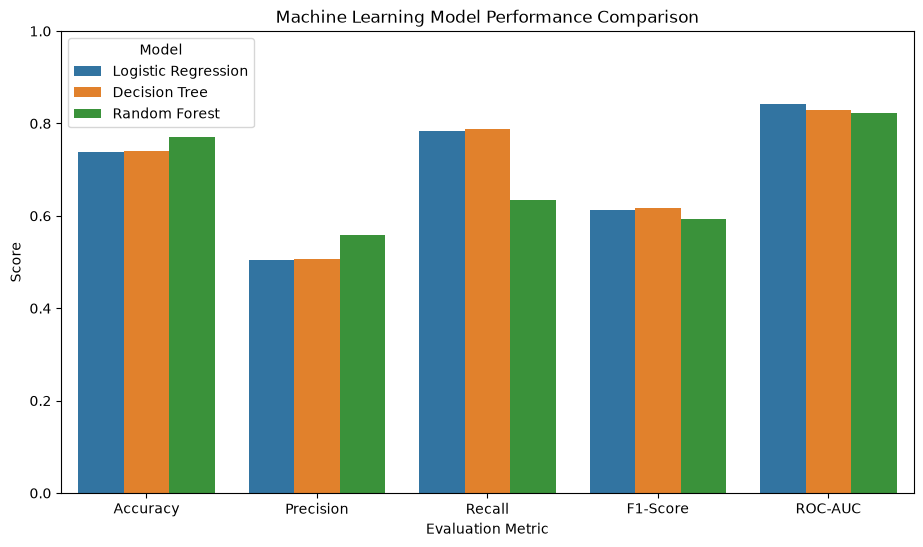

In [11]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Model")
plt.show()

In [12]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8416
1,Decision Tree,0.7402,0.5069,0.7888,0.6172,0.8284
2,Random Forest,0.7700,0.5590,0.6337,0.5940,0.8225



Logistic Regression
[[747 288]
 [ 81 293]]


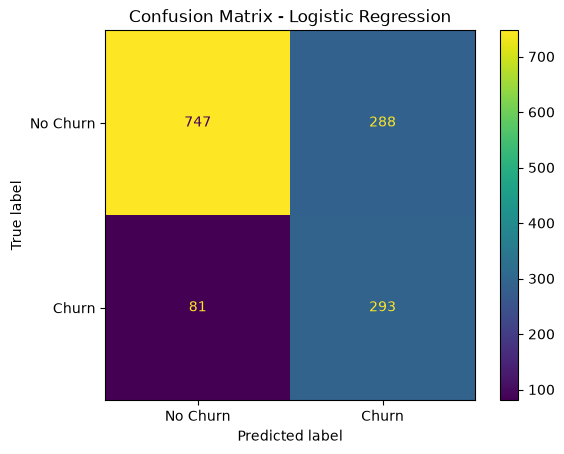


Decision Tree
[[748 287]
 [ 79 295]]


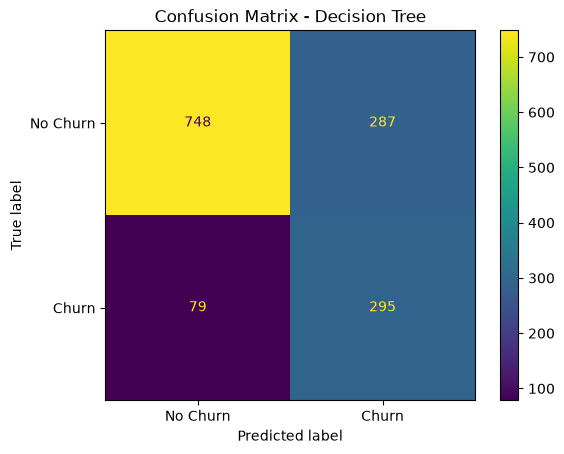


Random Forest
[[848 187]
 [137 237]]


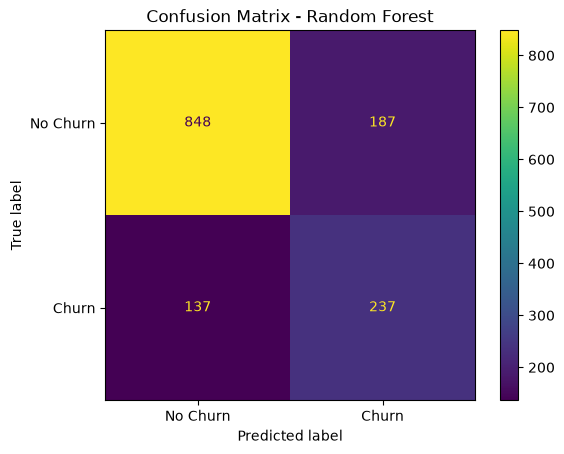

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


Logistic Regression
[[747 288]
 [ 81 293]]


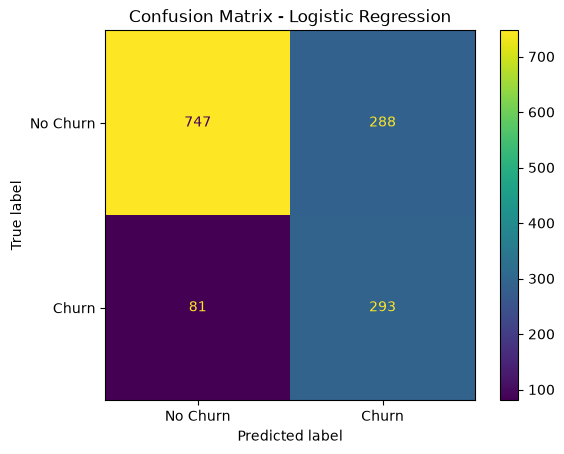


Decision Tree
[[748 287]
 [ 79 295]]


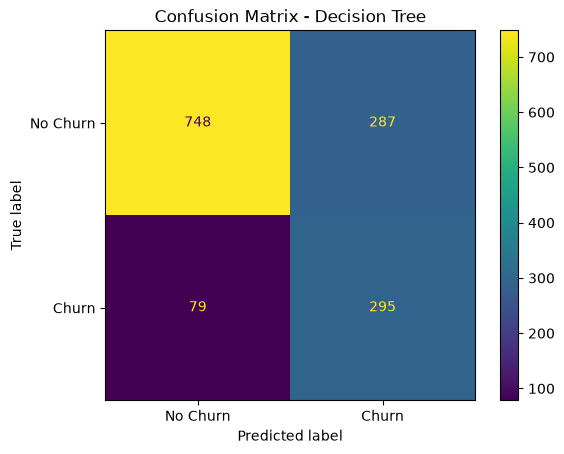


Random Forest
[[848 187]
 [137 237]]


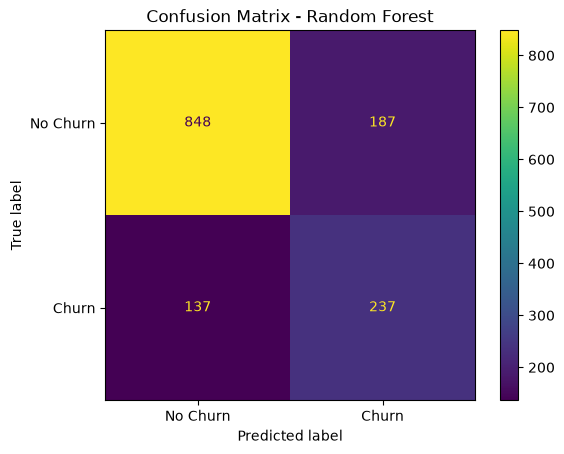

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



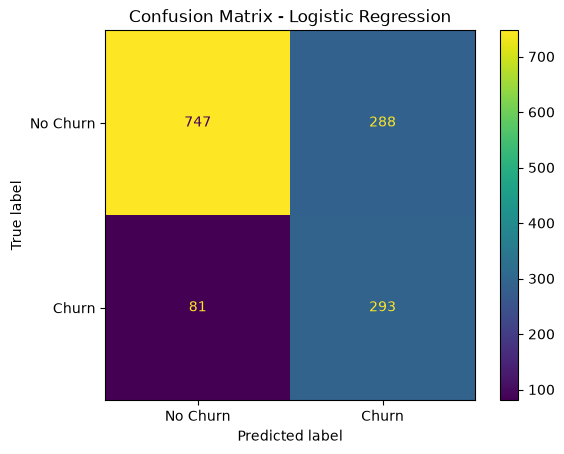

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



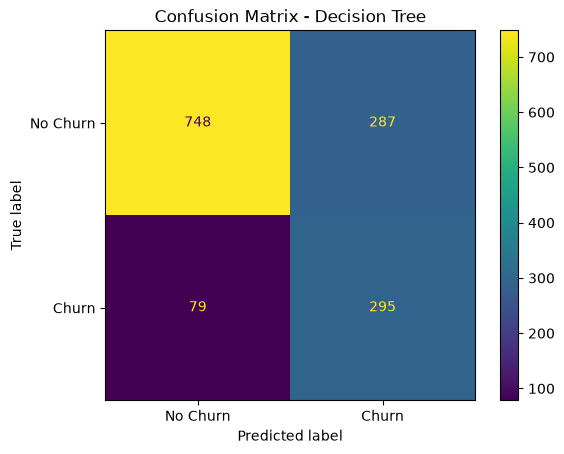

Random Forest
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409



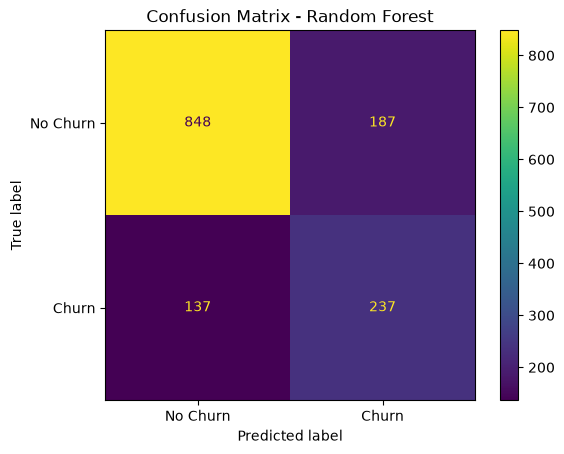

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)
    
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    ))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

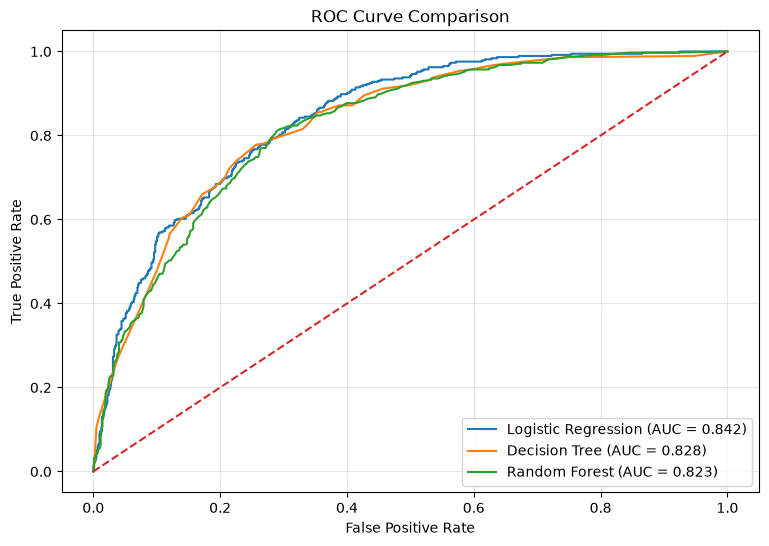

In [16]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 6))

for name, pipeline in trained_models.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
rf_pipeline = trained_models["Random Forest"]

rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__TotalCharges,0.142949
1,num__tenure,0.132617
2,num__MonthlyCharges,0.121519
36,cat__Contract_Month-to-month,0.069494
18,cat__OnlineSecurity_No,0.037852
38,cat__Contract_Two year,0.034355
27,cat__TechSupport_No,0.033805
43,cat__PaymentMethod_Electronic check,0.029456
16,cat__InternetService_Fiber optic,0.028295
21,cat__OnlineBackup_No,0.017774


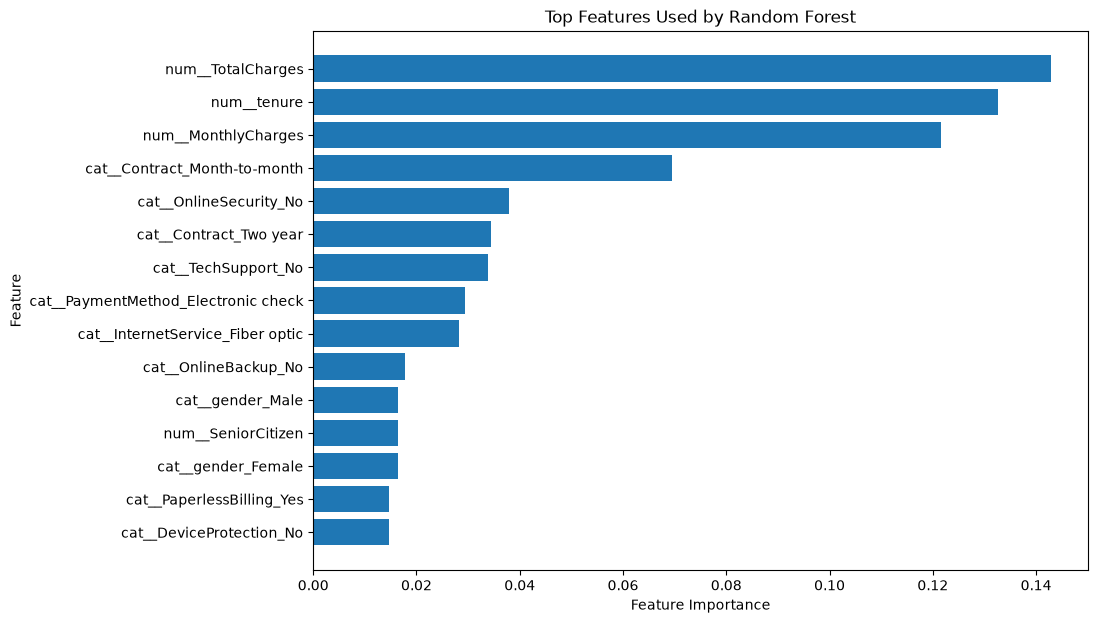

In [18]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Used by Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [19]:
feature_importance.to_csv(
    "../outputs/results/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [20]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

for name, pipeline in trained_models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    
    joblib.dump(
        pipeline,
        f"../models/{filename}"
    )
    
    print(f"{name} saved as {filename}")

Logistic Regression saved as logistic_regression.pkl
Decision Tree saved as decision_tree.pkl
Random Forest saved as random_forest.pkl


In [21]:
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,0.7402,0.5069,0.7888,0.6172,0.8284
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8416
2,Random Forest,0.7700,0.5590,0.6337,0.5940,0.8225


In [ ]:
import os

os.makedirs("../outputs/results", exist_ok=True)

results_df.to_csv(
    "../outputs/results/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")